In [39]:
import cv2
import yaml
import os
os.chdir('/home/iram/cmap/athirdmapper/exp01_0610')

# Load the map.pgm file
map = cv2.imread('map.pgm', cv2.IMREAD_GRAYSCALE)

# Load the map.yaml file
with open('map.yaml', 'r') as file:
    map_data = yaml.safe_load(file)

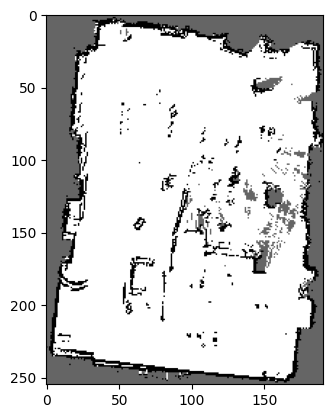

In [40]:
import matplotlib.pyplot as plt
import numpy as np
plt.imshow(map, cmap='gray')
np.unique(map)
# 101 = unknown space
# 0 = occupied space
# 100 = free space
_map = np.copy(map)
_map[map == 100] = 255
plt.imshow(_map, cmap='gray')

In [41]:
import os
import pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
def similarity(image_features, text_features):
    if torch.cuda.is_available(): 
        return image_features @ text_features.cpu().numpy().T
    return image_features @ text_features.numpy().T
def show_candidates(ind):
    for i, img_ind in enumerate(ind):
        r = len(ind)//9+1
        plt.figure('candidates', figsize=(12, r*2))
        plt.subplot(r, 9, i+1)
        img = cv2.imread('n_images/' + str(img_ind) + '.png')
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.tight_layout()
with open('features.pkl', 'rb') as file:
    features = pickle.load(file)
with open('features_ind.pkl', 'rb') as file:
    features_ind = pickle.load(file)
with open('text_features.pkl', 'rb') as file:
    text_features = pickle.load(file)
print(text_features['list'])

['umbrella', 'fire extinguisher', 'a single traffic cone', 'luggage', 'rc car', 'pile of traffic cone']


0.11428649312410448 8.977438088320839e-09 28


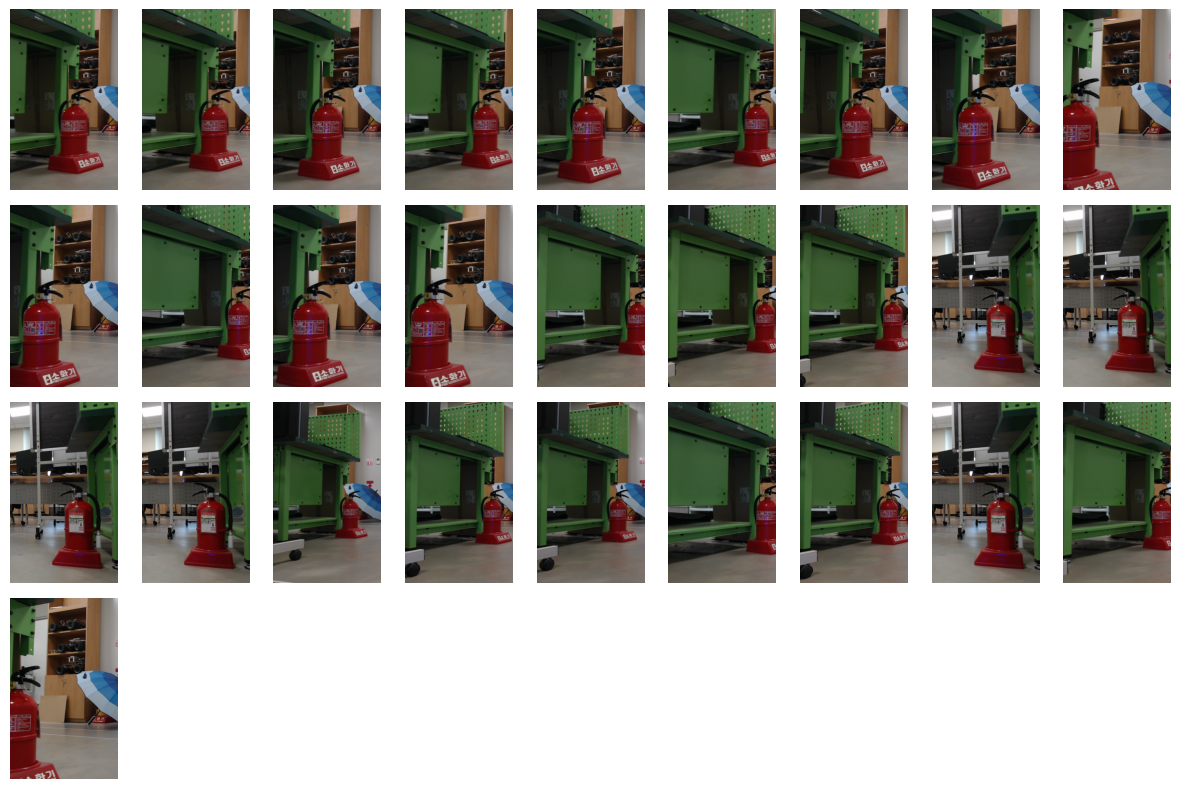

In [42]:
text_feature = text_features['fire extinguisher']
similarities = similarity(features, text_feature).squeeze()*100
# get softmax
similarities_s = F.softmax(torch.tensor(similarities), dim=0).numpy()
similarities_s
M_s = np.max(similarities_s)
m_s = np.min(similarities_s)
nsim = np.zeros_like(similarities_s)
nsim[similarities_s > 0.01] = 1
m = int(np.sum(nsim))
# nsim[similarities_s < 0.01] = 0
# n = int(np.sum(nsim))
print(M_s, m_s, m)

sim_sort_ind = np.argsort(similarities, axis=0)[::-1]
sim_sort_ind = sim_sort_ind[:m]
show_candidates(sim_sort_ind)

In [43]:
# print(sim_sort_ind)
# print(similarities_s[sim_sort_ind])
# get unique points
conf = {}
for index in sim_sort_ind:
    # print(len(features_ind[index]), features_ind[index])
    similarities_s = similarities[index]
    n_point = len(features_ind[index])
    for point in features_ind[index]:
        [s, n] = conf.get(tuple(point), [0,0])
        conf[tuple(point)] = [(s * n + similarities_s) / (n + 1), n + 1]
# sort confidence by value
conf_score = dict(sorted(conf.items(), key=lambda item: item[1], reverse=True))
conf_freq = dict(sorted(conf.items(), key=lambda item: item[1][1], reverse=True))
k = list(conf_score.keys())
v = list(conf_score.values())
print(k)
print(v)

K = list(conf_freq.keys())
V = list(conf_freq.values())
print(K)
print(V)

[(-3.0, 0.75, 0.0), (-3.25, 0.0, 0.0), (-3.25, -0.25, 0.0), (-4.5, -0.25, 0.0), (-3.0, 0.5, 0.0), (-3.25, 0.25, 0.0), (-4.75, -0.25, 0.0), (-2.75, -0.25, 0.0), (-3.0, 0.0, 0.0), (-3.0, -0.25, 0.0), (-3.0, 0.25, 0.0), (-2.75, 0.0, 0.0), (-1.75, 0.75, 0.0), (-2.25, 0.5, 0.0), (-2.5, 0.5, 0.0), (-1.75, 1.0, 0.0)]
[[10.21802126289965, 21], [10.199607385912065, 18], [10.154934385915126, 8], [10.110090448543, 6], [10.090950733129953, 26], [10.082011030390827, 23], [10.014785090134382, 4], [9.900496319866647, 2], [9.829241499010521, 8], [9.779053468461207, 9], [9.692526833208603, 14], [9.65600031756253, 2], [9.633942756530208, 3], [9.544098910899379, 4], [9.415800042870615, 1], [9.36351640847306, 1]]
[(-3.0, 0.5, 0.0), (-3.25, 0.25, 0.0), (-3.0, 0.75, 0.0), (-3.25, 0.0, 0.0), (-3.0, 0.25, 0.0), (-3.0, -0.25, 0.0), (-3.25, -0.25, 0.0), (-3.0, 0.0, 0.0), (-4.5, -0.25, 0.0), (-4.75, -0.25, 0.0), (-2.25, 0.5, 0.0), (-1.75, 0.75, 0.0), (-2.75, -0.25, 0.0), (-2.75, 0.0, 0.0), (-2.5, 0.5, 0.0), (-1.

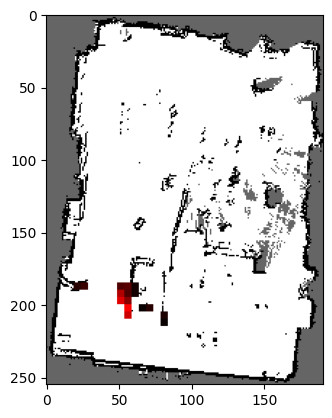

In [44]:
def point2pixel(point, map_data):
    origin = map_data['origin']
    resolution = map_data['resolution']
    return (int((point[0] - origin[0]) / resolution),
            int((point[1] - origin[1]) / resolution))
def probmap(conf, map, map_data, grid_size, mode='freq'):
    d = 0 if mode == 'score' else 1
    max_p = max(conf.values(), key=lambda x: x[d])[d]
    grid_pixel = int(grid_size / map_data['resolution'] // 2)
    map_image = np.copy(map)
    map_image = cv2.cvtColor(map_image, cv2.COLOR_GRAY2BGR)
    for point, score in conf.items():
        x, y = point2pixel(point, map_data)
        p = score[d] / max_p
        color = (int(p * 255),0,0)
        #cv2.circle(map_image, (x, y), 4, color, -1)
        cv2.rectangle(map_image, (x-grid_pixel,y-grid_pixel), (x+grid_pixel,y+grid_pixel), color, -1)
    return map_image
map[map == 100] = 255
map_ = probmap(conf_score, map, map_data, 0.25)
plt.imshow(map_)

In [49]:
map_image = np.copy(map)

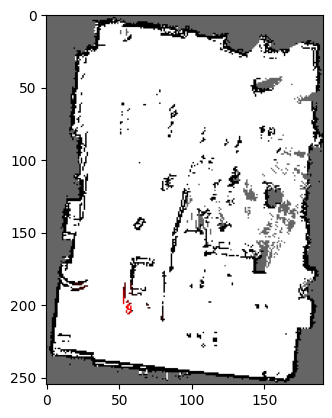

In [64]:
def probmap(conf, map, map_data, grid_size, mode='freq'):
    d = 0 if mode == 'score' else 1
    max_p = max(conf.values(), key=lambda x: x[d])[d]
    grid_pixel = int(grid_size / map_data['resolution'] // 2)
    map_image = np.copy(map)
    map_image = cv2.cvtColor(map_image, cv2.COLOR_GRAY2BGR)
    for point, score in conf.items():
        x, y = point2pixel(point, map_data)
        p = score[d] / max_p
        color = (255,0,0)
        #cv2.circle(map_image, (x, y), 4, color, -1)
        rec = np.zeros_like(map_image)

        cv2.rectangle(rec, (x-grid_pixel,y-grid_pixel), (x+grid_pixel,y+grid_pixel), color, -1)
        mask = rec.astype(bool)

        map_image[mask] = cv2.addWeighted(map_image, 1, rec, p, 0)[mask]
    return map_image

map_image[map == 100] = 255
map_ = probmap(conf_score, map_image, map_data, 0.25)
plt.imshow(map_)

In [46]:
img = np.zeros_like(map_image)
plt.imshow(img, cma)

NameError: name 'cma' is not defined